Differences (Before - After): [8 5 9 5 3 6 8 2 9 6]
Mean difference = 6.10 mmHg, SD of differences = 2.42
t statistic = 7.9565
t critical = 1.8331 (one-tailed, df = 9)
p-value = 0.000012

Decision: Reject H0 -> Yoga significantly reduced blood pressure.


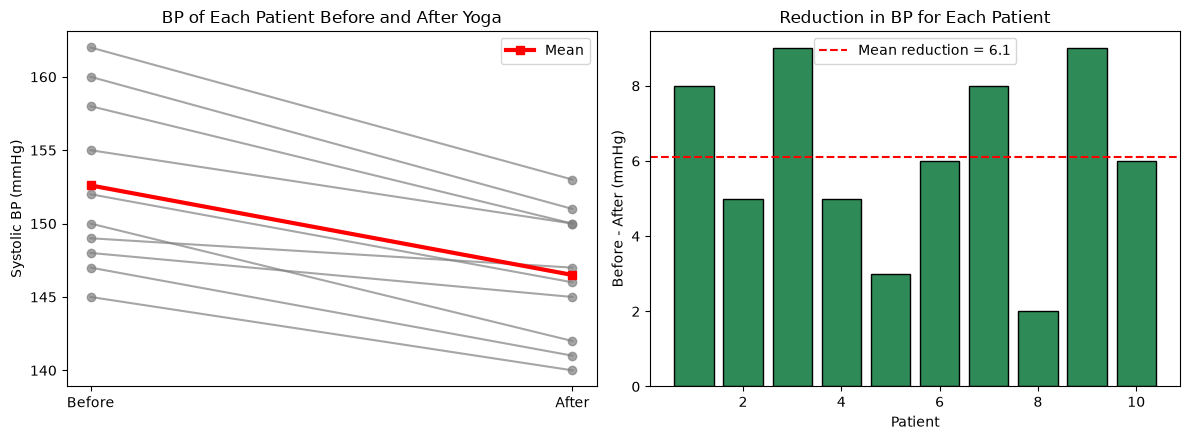

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data - BP of the same 10 patients
before = np.array([
    150, 145, 160, 155, 148,
    152, 158, 149, 162, 147
])

after = np.array([
    142, 140, 151, 150, 145,
    146, 150, 147, 153, 141
])

diff = before - after
alpha = 0.05
n = len(diff)

# Step 2: Paired t-test
# One-tailed: Before > After
t_stat, p_value = stats.ttest_rel(
    before,
    after,
    alternative='greater'
)

t_critical = stats.t.ppf(
    1 - alpha,
    n - 1
)

print("Differences (Before - After):", diff)

print(
    f"Mean difference = {diff.mean():.2f} mmHg, "
    f"SD of differences = {diff.std(ddof=1):.2f}"
)

print(f"t statistic = {t_stat:.4f}")

print(
    f"t critical = {t_critical:.4f} "
    f"(one-tailed, df = {n - 1})"
)

print(f"p-value = {p_value:.6f}")

# Step 3: Decision
if p_value < alpha:
    print(
        "\nDecision: Reject H0 -> "
        "Yoga significantly reduced blood pressure."
    )
else:
    print(
        "\nDecision: Fail to reject H0 -> "
        "No significant reduction in blood pressure."
    )

# Step 4: Graphs
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Graph 1: Before vs After for each patient
for i in range(n):
    ax[0].plot(
        ['Before', 'After'],
        [before[i], after[i]],
        marker='o',
        color='gray',
        alpha=0.7
    )

# Mean before and after
ax[0].plot(
    ['Before', 'After'],
    [before.mean(), after.mean()],
    marker='s',
    color='red',
    lw=3,
    label='Mean'
)

ax[0].set_title('BP of Each Patient Before and After Yoga')
ax[0].set_ylabel('Systolic BP (mmHg)')
ax[0].legend()

# Graph 2: Reduction in BP
ax[1].bar(
    range(1, n + 1),
    diff,
    color='seagreen',
    edgecolor='black'
)

ax[1].axhline(
    diff.mean(),
    color='red',
    linestyle='--',
    label=f'Mean reduction = {diff.mean():.1f}'
)

ax[1].set_title('Reduction in BP for Each Patient')
ax[1].set_xlabel('Patient')
ax[1].set_ylabel('Before - After (mmHg)')
ax[1].legend()

plt.tight_layout()
plt.show()